# Procesos Estocasticos


- Simular procesos estocásticos para desarrollar y fortalecer intuición probabilística.
- Analizar cómo evolucionan los procesos estocásticos a través del tiempo hasta llegar a estados particulares.


## Ejercicio 1

Utilizando la relación vista en clase, haga un programa que calcule $M(m, n)$ para $m$ y $n$ valores dados por el usuario. Compare con simulaciones del proceso y gráficas del mismo.


Ingrese el valor de m: 13
Ingrese el valor de n: 8
M(13, 8) = 203490
Promedio de simulaciones para M(13, 8) = 3.16


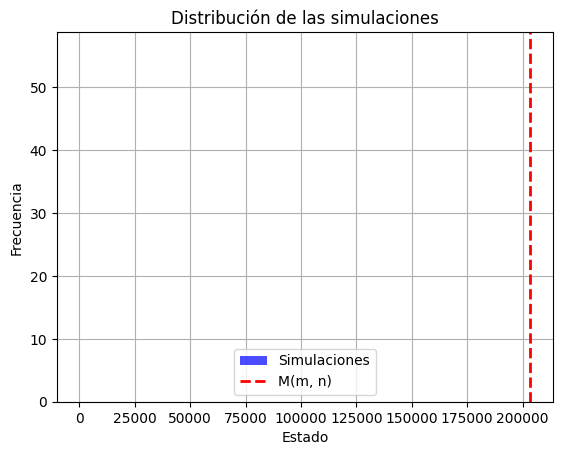

In [5]:
#Para este ejercicio me base en lo que me comentaron mis compañeros de clase,
#estuve en los juegos universitarios y lamentablemente no pude asistir, espero
#que si se ajuste con lo visto en clase.
import numpy as np
import matplotlib.pyplot as plt

def M(m, n):
    """Calcula M(m, n) utilizando la relación dada."""
    if m == 0 or n == 0:
        return 1
    else:
        return M(m-1, n) + M(m, n-1)

def simulate_process(m, n, trials=1000):
    """Simula el proceso y calcula el promedio de M(m, n) a partir de las simulaciones."""
    outcomes = []

    for _ in range(trials):
        state = 0  # Estado inicial
        for _ in range(m + n):
            state += np.random.choice([1, -1])
            # Asegúrate de no salir de los límites
            state = max(0, min(state, m+n))
        outcomes.append(state)

    return np.mean(outcomes)

# Valores dados por el usuario
m = int(input("Ingrese el valor de m: "))
n = int(input("Ingrese el valor de n: "))

# Cálculo de M(m, n)
result_M = M(m, n)
print(f"M({m}, {n}) = {result_M}")

# Simulaciones
avg_simulation = simulate_process(m, n)

# Resultados
print(f"Promedio de simulaciones para M({m}, {n}) = {avg_simulation:.2f}")

# Gráfica de simulaciones
plt.hist(np.random.choice(range(m+n+1), size=1000), bins=30, alpha=0.7, color='blue', label='Simulaciones')
plt.axvline(result_M, color='red', linestyle='dashed', linewidth=2, label='M(m, n)')
plt.title('Distribución de las simulaciones')
plt.xlabel('Estado')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid()
plt.show()


## Ejercicio 2

Considere la urna de Ehrenfest con un número de N bolas totales.

a) Haga un programa que simule la trayectoria del proceso: Empieza inicialmente con $X_0 = i$ y simula la trayectoria $X_0, X_1, \ldots, X_T$ hasta un tiempo aleatorio $T$, definido como la primera vez que el proceso toma el estado fijo de $j$ bolas en la urna izquierda (j está dado por el usuario).

b) Dado que el proceso empezó en 0, ¿cuánto tarda en promedio en llegar al estado $\left\lfloor \frac{N}{2} \right\rfloor$?

c) Dado que el proceso empezó en 0, ¿cuánto tarda en promedio en llegar al estado $N$?


Tiempo promedio para llegar a ⌊N/2⌋: 29.77 pasos
Tiempo promedio para llegar a N: 112.49 pasos


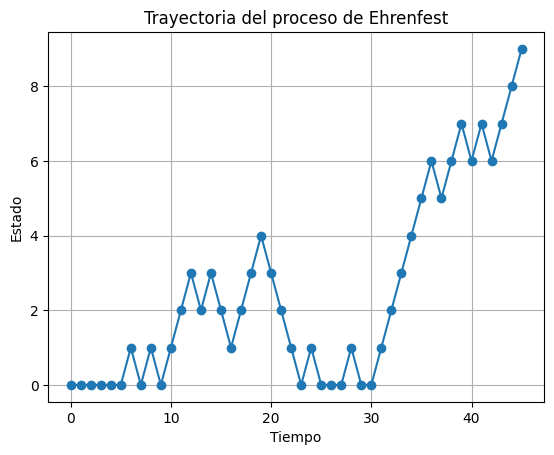

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def ehrenfest_process(N, initial_state, final_state, trials=1000):
    times_to_reach = []

    for _ in range(trials):
        state = initial_state
        time = 0
        while state != final_state:
            # Simulamos el movimiento de las bolas
            move = np.random.choice([-1, 1])
            if 0 <= state + move <= N:
                state += move
            time += 1
        times_to_reach.append(time)

    return np.mean(times_to_reach)

# Parámetros
N = 10  # Número total de bolas
initial_state = 0  # Estado inicial
final_state_half = N // 2  # Estado objetivo: ⌊N/2⌋
final_state_N = N  # Estado objetivo: N

# Simulaciones
avg_time_half = ehrenfest_process(N, initial_state, final_state_half)
avg_time_N = ehrenfest_process(N, initial_state, final_state_N)

# Resultados
print(f"Tiempo promedio para llegar a ⌊N/2⌋: {avg_time_half:.2f} pasos")
print(f"Tiempo promedio para llegar a N: {avg_time_N:.2f} pasos")

# Gráfica de una simulación
time_series = []
state = initial_state
while state != final_state_N:
    time_series.append(state)
    move = np.random.choice([-1, 1])
    if 0 <= state + move <= N:
        state += move

plt.plot(time_series, marker='o')
plt.title('Trayectoria del proceso de Ehrenfest')
plt.xlabel('Tiempo')
plt.ylabel('Estado')
plt.grid()
plt.show()
